# Neural Network for Stress Prediction

Surrogate model to predict stress from wing geometry parameters (`W1`, `W2`, `R`, `t`), trained on FEA simulation data. Architecture and hyperparameters are selected via cross-validation and compared against the GPR baseline.

## Imports

In [5]:
# Import necessary libraries
import time
import pandas as pd
import numpy as np
from pathlib import Path
import torch
import joblib
import matplotlib.pyplot as plt
from torch import nn
from sklearn.exceptions import ConvergenceWarning
from dataclasses import dataclass
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import warnings

# Suppress lbfgs convergence noise
warnings.filterwarnings('ignore', category=ConvergenceWarning)

## Constants

In [6]:
# Set a fixed random state for reproducibility across all random operations
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
# Set the path to the dataset
DATA_PATH = "../data/TrainingData_256.csv"
# Set device to run model on
DEVICE = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"

In [7]:
# Check model is running on apple silicon
print(f"Using {DEVICE} device")

Using mps device


## Data Pre-Processing

### Load & Inspect Dataset

In [8]:
# Load the dataset into pandas dataframe
df = pd.read_csv(DATA_PATH)
# Print first 5 rows of the dataframe
df.head()

,W1,W2,R,t,MaxVonMisesStress_MPa
0,0.30,0.10000,0.030,0.01000,80.611312
1,0.50,0.12500,0.050,0.01500,44.253276
2,0.40,0.13750,0.040,0.01750,48.132708
3,0.60,0.11250,0.060,0.01250,45.352288
4,0.35,0.13125,0.065,0.01875,39.334132


In [9]:
# Convert to numpy array
X = df.drop('MaxVonMisesStress_MPa', axis=1).to_numpy()          
y = df['MaxVonMisesStress_MPa'].to_numpy()

### Train / Test Split

In [10]:
# Split the dataset into training and testing sets (80% train, 20% test) - Random state is set for reproducibility
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

## Model Architecture & Hyperparameter Selection

### Helper Functions

In [11]:
# # Scale the features and target variable using StandardScaler
# @dataclass # A dataclass to hold the scaled data and scalers for features and target variable
# class ScaledData:
#     X_train: np.ndarray # Scaled training features
#     X_test: np.ndarray # Scaled testing features
#     y_train: np.ndarray # Scaled training target variable
#     y_test: np.ndarray # Scaled testing target variable
#     feature_scaler: StandardScaler # Scaler used for features
#     target_scaler: StandardScaler # Scaler used for target variable

#     # Static method to scale the training and testing data using StandardScaler
#     @staticmethod
#     def scale_data(X_train, X_test, y_train, y_test):
#         feature_scaler = StandardScaler() # Scaler for features
#         target_scaler = StandardScaler() # Scaler for target variable

#         # Fit the feature scaler on the training features and transform both training and testing features
#         return ScaledData(
#             X_train=feature_scaler.fit_transform(X_train),
#             X_test=feature_scaler.transform(X_test),
#             y_train=target_scaler.fit_transform(y_train.reshape(-1, 1)).flatten(),
#             y_test=target_scaler.transform(y_test.reshape(-1, 1)).flatten(),
#             feature_scaler=feature_scaler,
#             target_scaler=target_scaler,
#         )

In [12]:
# Function to build a multi-layer perceptron (MLP) model with specified parameters
def build_mlp(n_inputs=4, hidden_layers=(32, 32), activation='relu', dropout=0.0): # default values for parameters
    # Dictionary mapping activation function names to their corresponding PyTorch activation functions
    act = {
        'relu': nn.ReLU(),
        'ELU': nn.ELU(),
        'tanh': nn.Tanh(),
        'sine': nn.SiLU(),
        'sigmoid': nn.Sigmoid(),
        'soft_plus': nn.Softplus(),
    }
    
    # Check if the specified activation function is supported, if not raise a ValueError
    if activation not in act:
            raise ValueError(f"Unsupported activation function: {activation}")
    
    # Build the layers of the MLP based on the specified hidden layer sizes, activation function, and dropout rate
    # list to hold the layers of the MLP
    layers = []
    prev = n_inputs # number of input features
    # Loop through the specified hidden layer sizes and add the corresponding layers to the MLP
    for h in hidden_layers:
        # Add a linear layer with 'prev' input features and 'h' output features, followed by the specified activation function and dropout (if any)
        layers.append(nn.Linear(prev, h))
        layers.append(act[activation])
        if dropout > 0: # Add dropout layer if dropout rate is greater than 0
            layers.append(nn.Dropout(dropout))
        prev = h
    layers.append(nn.Linear(prev, 1))  # linear output for regression
    # Return the MLP model as a sequential container of layers
    return nn.Sequential(*layers)

In [13]:
# Function to train the MLP model on the training data and evaluate on the validation data
def train_model(model, X_tr, y_tr, X_val, y_val, lr=1e-3, optimiser='adam', loss_fn='mse', batch_size=32, weight_decay=0.0, max_epochs=100, patience=10): # default values for parameters
# Convert numpy arrays to PyTorch tensors (float32 is standard for NN)
    Xt = torch.tensor(X_tr, dtype=torch.float32)
    yt = torch.tensor(y_tr, dtype=torch.float32).view(-1, 1)
    Xv = torch.tensor(X_val, dtype=torch.float32)
    yv = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

    # Initalise optimisers and loss function
    if optimiser == 'adam': # Use Adam optimizer with learning rate of 0.001
        optim = torch.optim.Adam(model.parameters(), lr=lr)
    elif optimiser == 'sgd': # Use SGD optimizer with learning rate of 0.01 and momentum of 0.9
        optim = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimiser == 'rmsprop': # Use RMSprop optimizer with learning rate of 0.001 and alpha of 0.9
        optim = torch.optim.RMSprop(model.parameters(), lr=lr, alpha=0.9)
    elif optimiser == 'l-bfgs': # Use LBFGS optimizer with learning rate of 0.01 and max iterations of 20
        optim = torch.optim.LBFGS(model.parameters(), lr=lr, max_iter=20)
    else:
        raise ValueError(f"Unsupported optimiser: {optimiser}")
    
    loss_ft = {
        'mse': nn.MSELoss(), # Mean Squared Error loss function for regression
        'mae': nn.L1Loss(), # Mean Absolute Error loss function for regression
        'huber': nn.SmoothL1Loss(), # Huber loss function for regression (less sensitive to outliers than MSE)
        'neg_log_likelihood': nn.GaussianNLLLoss(), # Negative Log Likelihood loss function for regression (assumes Gaussian distribution of errors)
    }

    loader = DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=True) # Create DataLoader for training data

    # Early-stopping bookkeeping
    best_val = float('inf') # Initialise best validation loss to infinity
    best_state = None # Initialise best model state to None
    epochs_no_improve = 0 # Initialise counter for epochs with no improvement
    history = {'train_loss': [], 'val_loss': []} # Initialise history dictionary to store training and validation losses
 
    # Train the model for a maximum number of epochs, with early stopping based on validation loss
    for epoch in range(max_epochs):
        # training pass: minibatch SGD over the training set
        model.train()
        train_losses = [] # List to store training losses for each batch in the current epoch
        for xb, yb in loader: # Loop through each batch of training data
            optim.zero_grad() # Zero the gradients of the model parameters
            loss = loss_ft[loss_fn](model(xb), yb) # Compute the loss for the current batch using the specified loss function
            loss.backward() # Backpropagate the loss to compute gradients of the model parameters
            optim.step() # Update the model parameters using the computed gradients
            train_losses.append(loss.item()) # Append the loss for the current batch to the list of training losses for the current epoch
 
        # validation pass: evaluate the model on the validation set without updating weights
        model.eval()
        # Compute the validation loss using the specified loss function and store it in the history dictionary
        with torch.no_grad():
            val_loss = loss_ft[loss_fn](model(Xv), yv).item()
        history['train_loss'].append(float(np.mean(train_losses)))
        history['val_loss'].append(val_loss)
 
        # Early stopping check
        # If the validation loss has improved, update the best validation loss and save the current model state
        if val_loss < best_val:
            best_val = val_loss
            # Deep-copy current weights as the new best
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        # If the validation loss has not improved for a number of consecutive epochs equal to the patience parameter, stop training.
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break
 
    # Restore the best weights (not the final ones) before returning
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history, best_val, epoch + 1


In [14]:
# Function to evaluate the performance of the trained model on the test set and compute regression metrics in original units (MPa)
def evaluate(model, X_scaled, y_true_unscaled, target_scaler):
    # Set the model to evaluation mode
    model.eval()
    Xt = torch.tensor(X_scaled, dtype=torch.float32) # Convert the scaled test features to a PyTorch tensor
    with torch.no_grad(): # Disable gradient computation for evaluation
        y_pred_scaled = model(Xt).numpy().flatten() # Get the predicted values from the model and convert them to a NumPy array, then flatten it to a 1D array
    # Inverse-transform array back to MPa
    y_pred = target_scaler.inverse_transform(
        y_pred_scaled.reshape(-1, 1)
    ).flatten()
    
    err = y_pred - y_true_unscaled # Compute the error between the predicted values and the true unscaled target values
    rmse = float(np.sqrt(np.mean(err ** 2))) # Compute the Root Mean Squared Error (RMSE) between the predicted values and the true unscaled target values
    mae = float(np.mean(np.abs(err))) # Compute the Mean Absolute Error (MAE) between the predicted values and the true unscaled target values
    mape = float(np.mean(np.abs(err / y_true_unscaled)) * 100) # Compute the Mean Absolute Percentage Error (MAPE) between the predicted values and the true unscaled target values
    ss_res = float(np.sum(err ** 2)) # Compute the residual sum of squares (SS_res) between the predicted values and the true unscaled target values
    ss_tot = float(np.sum((y_true_unscaled - y_true_unscaled.mean()) ** 2)) # Compute the total sum of squares (SS_tot) between the true unscaled target values and their mean
    r2 = 1.0 - ss_res / ss_tot # Compute the R-squared (R2) score between the predicted values and the true unscaled target values
    # Return a dictionary containing the computed regression metrics and the predicted values
    return {'rmse': rmse, 'mae': mae, 'mape': mape, 'r2': r2,
            'y_pred': y_pred}

In [15]:
# Function to perform k-fold cross-validation for a given architecture/hyperparameter configuration of the MLP model
def cv_evaluate(X_train_raw, y_train_raw, build_kwargs, train_kwargs,
                k=5, seed=SEED, val_frac_in_fold=0.15): # default values for parameters
    
    # Set up k-fold cross-validation with shuffling and a fixed random state for reproducibility
    kf = KFold(n_splits=k, shuffle=True, random_state=seed)
    # Lists to store the MAPE, RMSE, training times, and number of epochs for each fold of cross-validation
    mapes, rmses, times, epochs = [], [], [], [] 
 
    # Loop through each fold of cross-validation, splitting the training data into training and evaluation sets for this fold
    for fold_idx, (tr_idx, eval_idx) in enumerate(kf.split(X_train_raw)):
        # Split the original (unscaled) training data into this fold's
        # train/eval sets - eval is what we report CV metrics on
        X_tr_raw = X_train_raw[tr_idx]
        y_tr_raw = y_train_raw[tr_idx]
        X_eval_raw = X_train_raw[eval_idx]
        y_eval_raw = y_train_raw[eval_idx]
 
        # Carve out an internal validation slice from this fold's train data
        # purely for early-stopping (NOT the same as the CV eval set)
        X_sub, X_es, y_sub, y_es = train_test_split(
            X_tr_raw, y_tr_raw,
            test_size=val_frac_in_fold, random_state=seed
        )
 
        # Fit scalers on this fold's training-only slice
        fs = StandardScaler().fit(X_sub)
        ts = StandardScaler().fit(y_sub.reshape(-1, 1))
 
        X_sub_s = fs.transform(X_sub) # Scale the training features for this fold using the fitted feature scaler
        X_es_s = fs.transform(X_es) # Scale the early stopping validation features for this fold using the fitted feature scaler
        X_eval_s = fs.transform(X_eval_raw) # Scale the evaluation features for this fold using the fitted feature scaler
        y_sub_s = ts.transform(y_sub.reshape(-1, 1)).flatten() # Scale the training target variable for this fold using the fitted target scaler
        y_es_s = ts.transform(y_es.reshape(-1, 1)).flatten() # Scale the early stopping validation target variable for this fold using the fitted target scaler
 
        # Build & train
        # Re-seed per fold so all configs get the same init pattern
        torch.manual_seed(seed + fold_idx)
        model = build_mlp(**build_kwargs)
 
        t0 = time.time() # Record the start time for training
        # Train the model on the scaled training data for this fold, using the early stopping validation data for early stopping
        model, _, _, n_epochs = train_model(
            model, X_sub_s, y_sub_s, X_es_s, y_es_s, **train_kwargs
        )
        times.append(time.time() - t0) # Record the training time for this fold
        epochs.append(n_epochs) # Record the number of epochs for this fold
 
        # Evaluate on the CV eval fold - in MPa
        m = evaluate(model, X_eval_s, y_eval_raw, ts)
        mapes.append(m['mape'])
        rmses.append(m['rmse'])
 
    # Return results dictionary
    return {
        'mape_mean': float(np.mean(mapes)), 'mape_std': float(np.std(mapes)),
        'rmse_mean': float(np.mean(rmses)), 'rmse_std': float(np.std(rmses)),
        'time_mean': float(np.mean(times)),
        'epochs_mean': float(np.mean(epochs)),
    }

In [16]:
# Function to count the number of trainable parameters in the model - reported in depth/width experiment tables
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

### Systematic Exploration of Architectures & Hyperparameters (ablation study)

#### Experiment 1: Activation function

In [17]:
print("\n=== Experiment 1: Activation function ===")
exp1_rows = [] # List to store the results of the activation function experiment for each activation function tested
for act in ['relu', 'ELU', 'tanh', 'sine', 'sigmoid', 'soft_plus']: # Loop through each activation function to test
    bk = {'hidden_layers': (32, 32), 'activation': act, 'dropout': 0.0} # Set fixed architecture for this experiment (2 hidden layers with 32 neurons each, no dropout) and vary the activation function
    tk = {'optimiser': 'adam', 'lr': 1e-3,
          'batch_size': 32, 'max_epochs': 500, 'patience': 20} # Set fixed training hyperparameters for this experiment (Adam optimiser with learning rate of 0.001, batch size of 32, maximum of 500 epochs, and early stopping patience of 20 epochs)
    # Perform cross-validation evaluation for this activation function and store the results in the exp1_rows list
    r = cv_evaluate(X_train_raw, y_train_raw, bk, tk)
    # Store the results for this activation function in the exp1_rows list, including the activation function name and the computed metrics from cross-validation
    exp1_rows.append({'activation': act, **r})
    print(f"  {act:12s}  CV MAPE = {r['mape_mean']:.3f} ± {r['mape_std']:.3f} %"
          f"   time = {r['time_mean']:.2f} s")
    
# Save the results of the activation function experiment to a CSV file
exp1 = pd.DataFrame(exp1_rows)
exp1.to_csv('../results/exp1_activation.csv', index=False)
 
# Select the best activation function based on the lowest mean MAPE from the cross-validation results and print it
BEST_ACT = exp1.sort_values('mape_mean').iloc[0]['activation']
print(f"Best activation: {BEST_ACT}")


=== Experiment 1: Activation function ===
  relu          CV MAPE = 1.689 ± 0.198 %   time = 0.60 s
  ELU           CV MAPE = 1.831 ± 0.350 %   time = 0.31 s
  tanh          CV MAPE = 1.369 ± 0.479 %   time = 0.48 s
  sine          CV MAPE = 1.247 ± 0.117 %   time = 0.24 s
  sigmoid       CV MAPE = 3.466 ± 0.325 %   time = 0.31 s
  soft_plus     CV MAPE = 1.399 ± 0.286 %   time = 0.55 s
Best activation: sine


#### Experiment 2: Depth

In [ ]:
print("\n=== Experiment 2: Depth ===")
exp2_rows = []  # List to store results for each depth configuration tested
for depth in [1, 2, 3, 4]:  # Loop through number of hidden layers (network depth) to test
    bk = {'hidden_layers': (32,) * depth, 'activation': BEST_ACT, 'dropout': 0.0}  # Fix width at 32 and use best activation from Exp 1; vary depth only
    tk = {'optimiser': 'adam', 'lr': 1e-3,
          'batch_size': 32, 'max_epochs': 500, 'patience': 20}  # Fixed training hyperparameters consistent with Exp 1
    r = cv_evaluate(X_train_raw, y_train_raw, bk, tk)  # Perform cross-validation for this depth configuration
    n_params = count_parameters(build_mlp(**bk))  # Count trainable parameters to show how model capacity grows with depth
    exp2_rows.append({'depth': depth, 'n_params': n_params, **r})  # Store depth, parameter count, and CV metrics
    print(f"  depth={depth}  params={n_params:5d}  "
          f"CV MAPE = {r['mape_mean']:.3f} ± {r['mape_std']:.3f} %")
exp2 = pd.DataFrame(exp2_rows)
exp2.to_csv('../results/exp2_depth.csv', index=False)  # Save depth experiment results to CSV

# Select best depth based on lowest mean CV MAPE and print it
BEST_DEPTH = int(exp2.sort_values('mape_mean').iloc[0]['depth'])
print(f"Best depth: {BEST_DEPTH}")



=== Experiment 2: Depth ===
  depth=1  params=  193  CV MAPE = 1.661 ± 0.137 %
  depth=2  params= 1249  CV MAPE = 1.247 ± 0.117 %
  depth=3  params= 2305  CV MAPE = 0.866 ± 0.131 %
  depth=4  params= 3361  CV MAPE = 0.766 ± 0.185 %
  -> Best depth: 4


#### Experiment 3: Width

In [ ]:
print("\n=== Experiment 3: Width ===")
exp3_rows = []  # List to store results for each width configuration tested
for width in [8, 16, 32, 64, 128]:  # Loop through neuron counts per hidden layer to test
    bk = {'hidden_layers': (width,) * BEST_DEPTH,
          'activation': BEST_ACT, 'dropout': 0.0}  # Fix depth and activation at best values from Exp 1-2; vary width only
    tk = {'optimiser': 'adam', 'lr': 1e-3,
          'batch_size': 32, 'max_epochs': 500, 'patience': 20}  # Fixed training hyperparameters consistent with earlier experiments
    r = cv_evaluate(X_train_raw, y_train_raw, bk, tk)  # Perform cross-validation for this width configuration
    n_params = count_parameters(build_mlp(**bk))  # Count trainable parameters to show how capacity grows with width
    exp3_rows.append({'width': width, 'n_params': n_params, **r})  # Store width, parameter count, and CV metrics
    print(f"  width={width:3d}  params={n_params:5d}  "
          f"CV MAPE = {r['mape_mean']:.3f} ± {r['mape_std']:.3f} %")
exp3 = pd.DataFrame(exp3_rows)
exp3.to_csv('../results/exp3_width.csv', index=False)  # Save width experiment results to CSV

# Select best width based on lowest mean CV MAPE and print it
BEST_WIDTH = int(exp3.sort_values('mape_mean').iloc[0]['width'])
print(f"Best width: {BEST_WIDTH}")



=== Experiment 3: Width ===
  width=  8  params=  265  CV MAPE = 1.951 ± 0.968 %
  width= 16  params=  913  CV MAPE = 0.998 ± 0.275 %
  width= 32  params= 3361  CV MAPE = 0.766 ± 0.185 %
  width= 64  params=12865  CV MAPE = 0.696 ± 0.141 %
  width=128  params=50305  CV MAPE = 0.627 ± 0.085 %
  -> Best width: 128


#### Experiment 4: Regularisation

In [33]:
print("\n=== Experiment 4: Regularisation ===")
# Each tuple defines: (scheme name, build kwargs for dropout, train kwargs for weight decay)
reg_configs = [
    ('none', {'dropout': 0.0}, {'weight_decay': 0.0}), # Baseline: no regularisation
    ('L2_1e-4', {'dropout': 0.0}, {'weight_decay': 1e-4}), # Light L2 penalty on weights via Adam's weight_decay
    ('L2_1e-3', {'dropout': 0.0}, {'weight_decay': 1e-3}), # Moderate L2 penalty
    ('L2_1e-2', {'dropout': 0.0}, {'weight_decay': 1e-2}), # Strong L2 penalty
    ('Dropout_0.1', {'dropout': 0.1}, {'weight_decay': 0.0}), # Light dropout (10% of neurons zeroed per forward pass)
    ('Dropout_0.2', {'dropout': 0.2}, {'weight_decay': 0.0}), # Moderate dropout
    ('L2_1e-3+Drop_0.1', {'dropout': 0.1}, {'weight_decay': 1e-3}), # Combined L2 + dropout
]
exp4_rows = []  # List to store results for each regularisation scheme tested
for name, build_extra, train_extra in reg_configs:  # Loop through each regularisation configuration
    bk = {'hidden_layers': (BEST_WIDTH,) * BEST_DEPTH,
          'activation': BEST_ACT, **build_extra}  # Use best architecture from Exp 1-3; apply current regularisation scheme
    tk = {'optimiser': 'adam', 'lr': 1e-3,
          'batch_size': 32, 'max_epochs': 500, 'patience': 20, **train_extra}  # Fixed training hyperparameters; apply current weight decay
    r = cv_evaluate(X_train_raw, y_train_raw, bk, tk)  # Perform cross-validation for this regularisation scheme
    exp4_rows.append({'scheme': name, **r})  # Store scheme name and CV metrics
    print(f"  {name:20s}  CV MAPE = {r['mape_mean']:.3f} ± {r['mape_std']:.3f} %")
exp4 = pd.DataFrame(exp4_rows)
exp4.to_csv('../results/exp4_regularisation.csv', index=False)  # Save regularisation experiment results to CSV

# Select best regularisation scheme based on lowest mean CV MAPE and extract dropout and weight decay values
BEST_REG = exp4.sort_values('mape_mean').iloc[0]
BEST_DROPOUT = float(reg_configs[exp4['mape_mean'].idxmin()][1]['dropout'])
BEST_WD = float(reg_configs[exp4['mape_mean'].idxmin()][2]['weight_decay'])
print(f"Best regularisation: {BEST_REG['scheme']} "
      f"(dropout={BEST_DROPOUT}, wd={BEST_WD})")



=== Experiment 4: Regularisation ===
  none                  CV MAPE = 0.627 ± 0.085 %
  L2_1e-4               CV MAPE = 0.627 ± 0.085 %
  L2_1e-3               CV MAPE = 0.627 ± 0.085 %
  L2_1e-2               CV MAPE = 0.627 ± 0.085 %
  Dropout_0.1           CV MAPE = 1.124 ± 0.195 %
  Dropout_0.2           CV MAPE = 1.482 ± 0.315 %
  L2_1e-3+Drop_0.1      CV MAPE = 1.124 ± 0.195 %
Best regularisation: none (dropout=0.0, wd=0.0)


#### Experiment 5: Optimiser

In [ ]:
print("\n=== Experiment 5: Optimiser ===")
exp5_rows = []  # List to store the best result for each optimiser tested
for opt in ['adam', 'sgd', 'rmsprop']:  # Loop through each optimiser to test
    # Sweep 3 LRs per optimiser, keep the best
    best_for_opt = None  # Track the lowest-MAPE result across all learning rates for this optimiser
    for lr in [1e-4, 1e-3, 1e-2]:  # Sweep three learning rates per optimiser to find its optimal setting
        bk = {'hidden_layers': (BEST_WIDTH,) * BEST_DEPTH,
              'activation': BEST_ACT, 'dropout': BEST_DROPOUT}  # Use best architecture and regularisation from Exp 1-4; vary optimiser
        tk = {'optimiser': opt, 'lr': lr, 'weight_decay': BEST_WD,
              'batch_size': 32, 'max_epochs': 500, 'patience': 20}  # Vary optimiser and learning rate; keep all other hyperparameters fixed
        r = cv_evaluate(X_train_raw, y_train_raw, bk, tk)  # Perform cross-validation for this optimiser/lr combination
        if best_for_opt is None or r['mape_mean'] < best_for_opt['mape_mean']:  # Keep only the best learning rate result for this optimiser
            best_for_opt = {'optimiser': opt, 'best_lr': lr, **r}
    exp5_rows.append(best_for_opt)  # Store the best result for this optimiser along with its optimal learning rate
    print(f"  {opt:8s}  best lr={best_for_opt['best_lr']:.0e}  "
          f"CV MAPE = {best_for_opt['mape_mean']:.3f} ± "
          f"{best_for_opt['mape_std']:.3f} %")
exp5 = pd.DataFrame(exp5_rows)
exp5.to_csv('../results/exp5_optimiser.csv', index=False)  # Save optimiser experiment results to CSV

# Select best optimiser based on lowest mean CV MAPE and print it
BEST_OPT = exp5.sort_values('mape_mean').iloc[0]['optimiser']
print(f"Best optimiser: {BEST_OPT}")      



=== Experiment 5: Optimiser ===
  adam      best lr=1e-03  CV MAPE = 0.627 ± 0.085 %
  sgd       best lr=1e-02  CV MAPE = 1.011 ± 0.135 %
  rmsprop   best lr=1e-04  CV MAPE = 1.153 ± 0.092 %
  -> Best optimiser: adam


#### Experiment 6: Learning rate

In [ ]:
print("\n=== Experiment 6: Learning rate ===")
exp6_rows = []  # List to store results for each learning rate tested
for lr in [1e-4, 3e-4, 1e-3, 3e-3, 1e-2]:  # Loop through a log-spaced grid of learning rates to test
    bk = {'hidden_layers': (BEST_WIDTH,) * BEST_DEPTH,
          'activation': BEST_ACT, 'dropout': BEST_DROPOUT}  # Use best architecture and regularisation from Exp 1-4
    tk = {'optimiser': BEST_OPT, 'lr': lr, 'weight_decay': BEST_WD,
          'batch_size': 32, 'max_epochs': 500, 'patience': 20}  # Use best optimiser from Exp 5; vary learning rate only
    r = cv_evaluate(X_train_raw, y_train_raw, bk, tk)  # Perform cross-validation for this learning rate
    exp6_rows.append({'lr': lr, **r})  # Store learning rate and CV metrics
    print(f"  lr={lr:.0e}  CV MAPE = {r['mape_mean']:.3f} ± {r['mape_std']:.3f} %")
exp6 = pd.DataFrame(exp6_rows)
exp6.to_csv('../results/exp6_lr.csv', index=False)  # Save learning rate experiment results to CSV

# Select best learning rate based on lowest mean CV MAPE and print it
BEST_LR = float(exp6.sort_values('mape_mean').iloc[0]['lr'])
print(f"Best learning rate: {BEST_LR}")


=== Experiment 6: Learning rate ===
  lr=1e-04  CV MAPE = 0.915 ± 0.105 %
  lr=3e-04  CV MAPE = 0.729 ± 0.158 %
  lr=1e-03  CV MAPE = 0.627 ± 0.085 %
  lr=3e-03  CV MAPE = 0.705 ± 0.155 %
  lr=1e-02  CV MAPE = 0.923 ± 0.133 %
  -> Best learning rate: 0.001


#### Experiment 7: Batch size

In [ ]:
print("\n=== Experiment 7: Batch size ===")
exp7_rows = []  # List to store results for each batch size tested
for bs in [16, 32, 64, len(X_train_raw)]:  # Loop through batch sizes including full-batch gradient descent (204 samples)
    bk = {'hidden_layers': (BEST_WIDTH,) * BEST_DEPTH,
          'activation': BEST_ACT, 'dropout': BEST_DROPOUT}  # Use best architecture and regularisation from Exp 1-4
    tk = {'optimiser': BEST_OPT, 'lr': BEST_LR, 'weight_decay': BEST_WD,
          'batch_size': bs, 'max_epochs': 500, 'patience': 20}  # Use best optimiser and learning rate from Exp 5-6; vary batch size only
    r = cv_evaluate(X_train_raw, y_train_raw, bk, tk)  # Perform cross-validation for this batch size
    exp7_rows.append({'batch_size': bs, **r})  # Store batch size and CV metrics
    print(f"  bs={bs:4d}  CV MAPE = {r['mape_mean']:.3f} ± {r['mape_std']:.3f} %"
          f"   time = {r['time_mean']:.2f} s")
exp7 = pd.DataFrame(exp7_rows)
exp7.to_csv('../results/exp7_batch.csv', index=False)  # Save batch size experiment results to CSV

# Select best batch size based on lowest mean CV MAPE and print it
BEST_BS = int(exp7.sort_values('mape_mean').iloc[0]['batch_size'])
print(f"Best batch size: {BEST_BS}")



=== Experiment 7: Batch size ===
  bs=  16  CV MAPE = 0.603 ± 0.136 %   time = 0.60 s
  bs=  32  CV MAPE = 0.627 ± 0.085 %   time = 0.57 s
  bs=  64  CV MAPE = 0.950 ± 0.174 %   time = 0.30 s
  bs= 204  CV MAPE = 0.718 ± 0.444 %   time = 2.69 s
  -> Best batch size: 16


#### Experiment 8: Training set size

In [ ]:
print("\n=== Experiment 8: Training set size scan ===")
exp8_rows = []  # List to store results for each training set size tested
for n in [20, 50, 100, 204]:  # Loop through training subsets to assess how performance scales with dataset size
    # Take the first n rows of the (already-shuffled) training data
    Xn = X_train_raw[:n]; yn = y_train_raw[:n]

    # Ensure at least 3 samples in the early-stopping validation split even for very small N
    val_frac = max(0.15, 3 / n)
    X_sub, X_es, y_sub, y_es = train_test_split(
        Xn, yn, test_size=val_frac, random_state=SEED)  # Split into training and early-stopping validation subsets
    fs = StandardScaler().fit(X_sub)  # Fit feature scaler on training subset only to avoid data leakage
    ts = StandardScaler().fit(y_sub.reshape(-1, 1))  # Fit target scaler on training subset only
    X_sub_s = fs.transform(X_sub); X_es_s = fs.transform(X_es)  # Scale training and early-stopping features
    y_sub_s = ts.transform(y_sub.reshape(-1, 1)).flatten()  # Scale training target variable
    y_es_s  = ts.transform(y_es.reshape(-1, 1)).flatten()   # Scale early-stopping target variable
    X_test_s = fs.transform(X_test_raw)  # Scale held-out test set using the training-fit scaler (no leakage)

    torch.manual_seed(SEED)  # Re-seed before each build to ensure fair comparison across dataset sizes
    model = build_mlp(hidden_layers=(BEST_WIDTH,) * BEST_DEPTH,
                      activation=BEST_ACT, dropout=BEST_DROPOUT)  # Build the fully-tuned best architecture
    t0 = time.time()
    model, _, _, n_epochs = train_model(
        model, X_sub_s, y_sub_s, X_es_s, y_es_s,
        optimiser=BEST_OPT, lr=BEST_LR, weight_decay=BEST_WD,
        batch_size=min(BEST_BS, n - len(X_es)),  # Clamp batch size so it never exceeds available training samples
        max_epochs=500, patience=20)
    train_t = time.time() - t0  # Record total training time for this dataset size

    # In-sample metrics (on the training subset the model actually saw)
    m_train = evaluate(model, X_sub_s, y_sub, ts)
    # Out-of-sample metrics (same held-out test set used throughout)
    m_test  = evaluate(model, X_test_s, y_test_raw, ts)

    exp8_rows.append({
        'n_samples':  n,
        'train_rmse': m_train['rmse'], 'test_rmse': m_test['rmse'],
        'train_mae':  m_train['mae'],  'test_mae':  m_test['mae'],
        'train_mape': m_train['mape'], 'test_mape': m_test['mape'],
        'train_time': train_t, 'epochs': n_epochs,
    })  # Store training set size, in-sample and out-of-sample metrics, training time, and epoch count
    print(f"  N={n:3d}  "
          f"Train RMSE={m_train['rmse']:.3f}  Test RMSE={m_test['rmse']:.3f} MPa  |  "
          f"Train MAE={m_train['mae']:.3f}  Test MAE={m_test['mae']:.3f} MPa  |  "
          f"Train MAPE={m_train['mape']:.3f}%  Test MAPE={m_test['mape']:.3f}%  "
          f"time={train_t:.2f}s  epochs={n_epochs}")
exp8 = pd.DataFrame(exp8_rows)
exp8.to_csv('../results/exp8_n_samples.csv', index=False)  # Save training set size scan results to CSV



=== Experiment 8: Training set size scan ===
  N= 20  Train RMSE=2.684  Test RMSE=6.735 MPa  |  Train MAE=2.187  Test MAE=3.670 MPa  |  Train MAPE=4.273%  Test MAPE=6.439%  time=0.19s  epochs=41
  N= 50  Train RMSE=0.264  Test RMSE=1.390 MPa  |  Train MAE=0.218  Test MAE=0.626 MPa  |  Train MAPE=0.476%  Test MAPE=1.114%  time=0.20s  epochs=100
  N=100  Train RMSE=0.528  Test RMSE=0.671 MPa  |  Train MAE=0.371  Test MAE=0.466 MPa  |  Train MAPE=0.734%  Test MAPE=0.903%  time=0.31s  epochs=81
  N=204  Train RMSE=0.204  Test RMSE=0.307 MPa  |  Train MAE=0.152  Test MAE=0.203 MPa  |  Train MAPE=0.308%  Test MAPE=0.418%  time=1.36s  epochs=181


## Final Model Training & Evaluation on Test Set

In [34]:
 # Apply the original 80:20 split's scaling and split off internal val for ES
X_sub_raw, X_val_raw, y_sub_raw, y_val_raw = train_test_split(
    X_train_raw, y_train_raw, test_size=0.15, random_state=SEED)
 
final_fs = StandardScaler().fit(X_sub_raw)
final_ts = StandardScaler().fit(y_sub_raw.reshape(-1, 1))
 
X_sub_s = final_fs.transform(X_sub_raw)
X_val_s = final_fs.transform(X_val_raw)
y_sub_s = final_ts.transform(y_sub_raw.reshape(-1, 1)).flatten()
y_val_s = final_ts.transform(y_val_raw.reshape(-1, 1)).flatten()
X_test_s_final = final_fs.transform(X_test_raw)
 
# Build and train the final model with all the best hyperparameters
torch.manual_seed(SEED)
final_model = build_mlp(
    hidden_layers=(BEST_WIDTH,) * BEST_DEPTH,
    activation=BEST_ACT,
    dropout=BEST_DROPOUT,
)
print(f"Architecture: {BEST_DEPTH} layers x {BEST_WIDTH} units, "
      f"act={BEST_ACT}, dropout={BEST_DROPOUT}, "
      f"params={count_parameters(final_model)}")
 
t0 = time.time()
final_model, history, best_val, n_epochs = train_model(
    final_model, X_sub_s, y_sub_s, X_val_s, y_val_s,
    optimiser=BEST_OPT, lr=BEST_LR, weight_decay=BEST_WD,
    batch_size=BEST_BS, max_epochs=500, patience=30)
train_time = time.time() - t0
print(f"Trained in {n_epochs} epochs ({train_time:.2f} s)")

Architecture: 4 layers x 128 units, act=sine, dropout=0.0, params=50305
Trained in 191 epochs (1.32 s)


In [36]:
test_metrics = evaluate(final_model, X_test_s_final, y_test_raw, final_ts)
print(f"  Test RMSE = {test_metrics['rmse']:.4f} MPa")
print(f"  Test MAE  = {test_metrics['mae']:.4f} MPa")
print(f"  Test MAPE = {test_metrics['mape']:.4f} %")
print(f"  Test R^2  = {test_metrics['r2']:.5f}")

  Test RMSE = 0.3065 MPa
  Test MAE  = 0.2029 MPa
  Test MAPE = 0.4177 %
  Test R^2  = 0.99937


## Saved Final Model

In [27]:
models_dir = Path('../models'); models_dir.mkdir(exist_ok=True)
results_dir = Path('../results'); results_dir.mkdir(exist_ok=True)
torch.save(final_model.state_dict(), models_dir / 'nn_surrogate.pt')
joblib.dump({'feature_scaler': final_fs, 'target_scaler': final_ts,
             'arch': {'hidden_layers': (BEST_WIDTH,) * BEST_DEPTH,
                      'activation': BEST_ACT, 'dropout': BEST_DROPOUT}},
            models_dir / 'nn_scalers.joblib')
# Also dump the metrics dict for the write-up
pd.DataFrame([{
    'rmse_mpa': test_metrics['rmse'],
    'mae_mpa': test_metrics['mae'],
    'mape_pct': test_metrics['mape'],
    'r2': test_metrics['r2'],
    'train_time_s': train_time,
    'epochs': n_epochs,
}]).to_csv(results_dir / 'final_metrics.csv', index=False)

print(f"\nModel saved to {models_dir.resolve()}")
print(f"Metrics saved to {results_dir.resolve()}")
print("Done.")


Model saved to /Users/evanlynch/Developer/plane-wing/models
Metrics saved to /Users/evanlynch/Developer/plane-wing/results
Done.


## Visualisations

In [28]:
# ---- Common plotting style for all visualisations ----
# One place to tweak so every report figure looks consistent.
import matplotlib as mpl
from matplotlib import gridspec
from matplotlib.colors import TwoSlopeNorm

mpl.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'legend.frameon': False,
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

# Colour palette (colour-blind friendly, from Wong 2011)
C_PRIMARY   = '#0072B2'  # blue  - NN / predictions
C_SECONDARY = '#D55E00'  # orange - validation / residuals
C_ACCENT    = '#009E73'  # green - highlights / ideal
C_NEUTRAL   = '#56B4E9'  # light blue
C_GREY      = '#555555'

# Units / labels used in multiple plots
FEATURE_LABELS = {
    0: r'$W_1$ (m)',
    1: r'$W_2$ (m)',
    2: r'$R$ (m)',
    3: r'$t$ (m)',
}
FEATURE_NAMES = ['W1', 'W2', 'R', 't']

In [29]:
# Quick LR-curve plot (the Goodfellow U-shape) - cheap and looks good in report
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.errorbar(exp6['lr'], exp6['mape_mean'], yerr=exp6['mape_std'],
            marker='o', capsize=4)
ax.set_xscale('log'); ax.set_xlabel('Learning rate')
ax.set_ylabel('CV MAPE (%)'); ax.set_title('Learning rate sensitivity')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.savefig('../figures/fig_lr_sweep.png', dpi=300); plt.close()

#### Loss Curves

Training and validation loss over epochs for the best architecture. Verify convergence and check for overfitting.

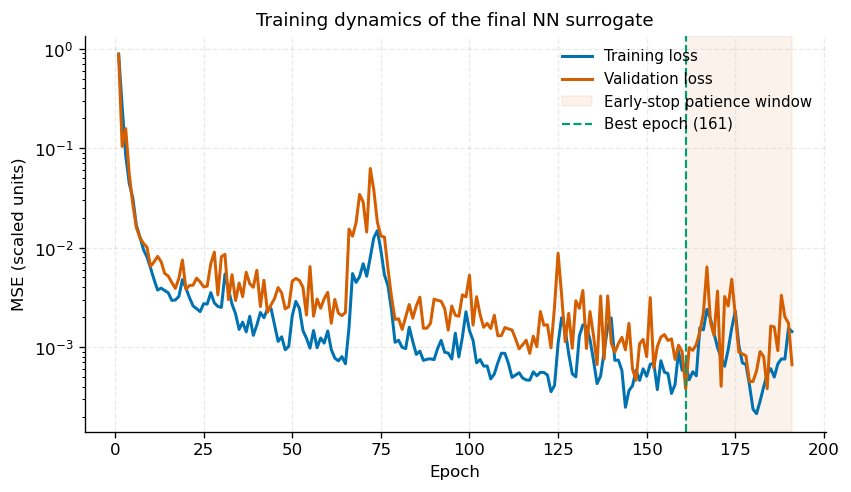

In [30]:
# ---- Figure: Training dynamics (loss curves + early-stop zoom inset) ----
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

train_losses = np.array(history['train_loss'])
val_losses = np.array(history['val_loss'])
best_epoch = int(np.argmin(val_losses))
stop_epoch = len(val_losses) - 1
epochs = np.arange(1, len(val_losses) + 1)

fig, ax = plt.subplots(figsize=(7.2, 4.2))

ax.plot(epochs, train_losses, color=C_PRIMARY, lw=1.8, label='Training loss')
ax.plot(epochs, val_losses, color=C_SECONDARY, lw=1.8, label='Validation loss')

# Shade the "patience" window (no-improvement streak that triggered early stop)
ax.axvspan(best_epoch + 1, stop_epoch + 1, color=C_SECONDARY,
           alpha=0.08, label='Early-stop patience window')
ax.axvline(best_epoch + 1, color=C_ACCENT, ls='--', lw=1.3,
           label=f'Best epoch ({best_epoch + 1})')

ax.set_xlabel('Epoch')
ax.set_ylabel('MSE (scaled units)')
ax.set_yscale('log')
ax.set_title('Training dynamics of the final NN surrogate')
ax.legend(loc='upper right', fontsize=9)


plt.tight_layout()
plt.savefig('../figures/fig_loss_curves.png')
plt.show()

## Comparison with GPR Baseline

Side-by-side comparison of the best NN against the best GPR model (Matern 2.5 kernel) on the same held-out test set. Metrics: Test RMSE, MAE, MAPE, training time, prediction time.

Metric                         GPR          NN       delta
----------------------------------------------------------
Test RMSE (MPa)             0.1602      0.3065     +0.1464
Test MAE (MPa)              0.1263      0.2029     +0.0766
Test MAPE (%)               0.2570      0.4177     +0.1607
Test R^2                    0.9998      0.9994     -0.0005


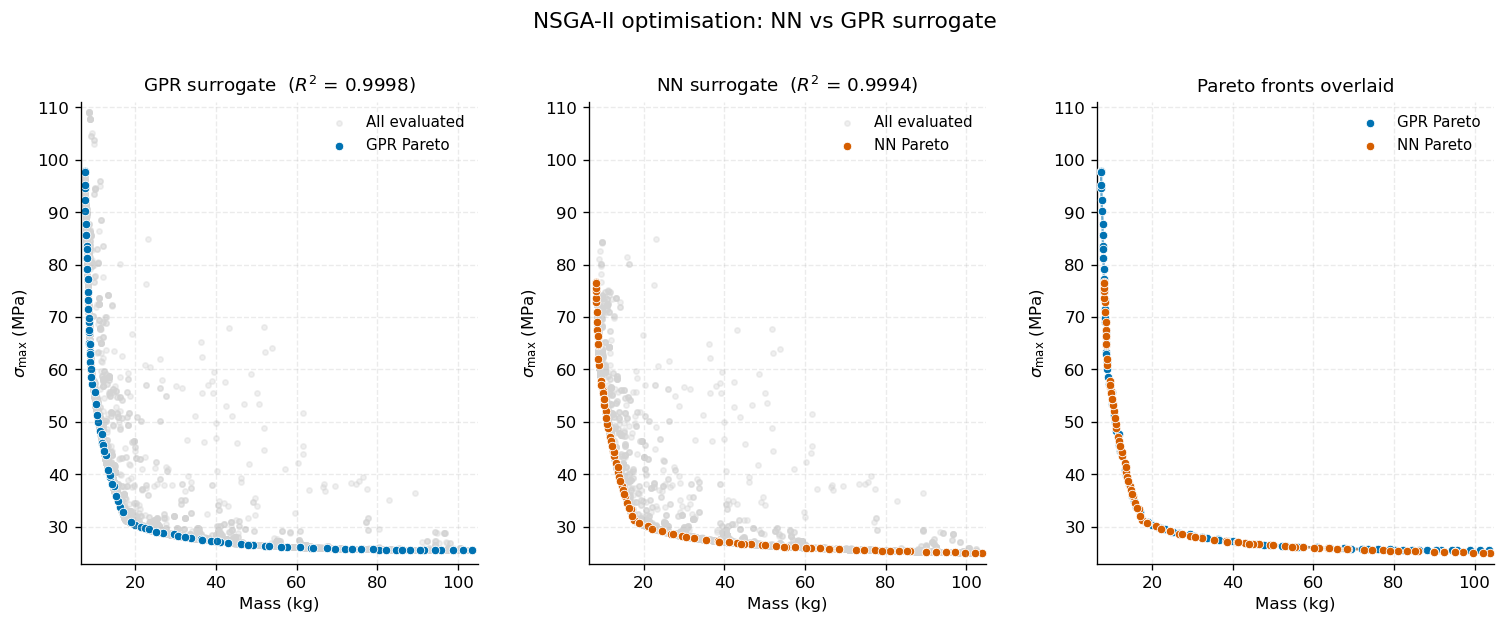

In [32]:
# ---- Side-by-side comparison: NN vs GPR surrogate ----
# Both Pareto fronts are produced by the two optimisation scripts:
#     src/MaintenancePlate_Optimisation.py       (GPR)
#     src/MaintenancePlate_Optimisation_NN.py    (NN)
# which save their fronts to models/pareto_front_{gpr,nn}.csv.
models_dir = Path('../models')
results_dir = Path('../results')
pf_gpr = pd.read_csv(results_dir / 'pareto_front_gpr.csv')
pa_gpr = pd.read_csv(results_dir / 'pareto_all_gpr.csv')
pf_nn = pd.read_csv(results_dir / 'pareto_front_nn.csv')
pa_nn = pd.read_csv(results_dir / 'pareto_all_nn.csv')

# ---- Re-evaluate GPR on the same held-out test set used for the NN ----
gpr_pipeline = joblib.load(models_dir / 'gpr_best_pipeline.pkl')
y_pred_gpr = gpr_pipeline.predict(X_test_raw)
err_gpr = y_pred_gpr - y_test_raw
rmse_gpr = float(np.sqrt(np.mean(err_gpr ** 2)))
mae_gpr = float(np.mean(np.abs(err_gpr)))
mape_gpr = float(np.mean(np.abs(err_gpr / y_test_raw)) * 100)
r2_gpr = 1.0 - float(
    np.sum(err_gpr ** 2) / np.sum((y_test_raw - y_test_raw.mean()) ** 2))

# Pretty comparison table (matches the format in the final_metrics CSV)
print(f"{'Metric':<22s}{'GPR':>12s}{'NN':>12s}{'delta':>12s}")
print('-' * 58)
for name, g, n in [
    ('Test RMSE (MPa)', rmse_gpr, test_metrics['rmse']),
    ('Test MAE (MPa)', mae_gpr, test_metrics['mae']),
    ('Test MAPE (%)', mape_gpr, test_metrics['mape']),
    ('Test R^2', r2_gpr, test_metrics['r2']),
]:
    delta = n - g
    print(f"{name:<22s}{g:>12.4f}{n:>12.4f}{delta:>+12.4f}")

# ---- Side-by-side figure: three panels with shared axes ----
xlim = (min(pa_gpr.mass_kg.min(), pa_nn.mass_kg.min()) - 1,
        max(pa_gpr.mass_kg.max(), pa_nn.mass_kg.max()) + 1)
ylim = (min(pa_gpr.stress_mpa.min(), pa_nn.stress_mpa.min()) - 2,
        max(pa_gpr.stress_mpa.max(), pa_nn.stress_mpa.max()) + 2)

fig, axes = plt.subplots(1, 3, figsize=(15.2, 5.0),
                         gridspec_kw={'wspace': 0.28})

# GPR panel
axes[0].scatter(pa_gpr.mass_kg, pa_gpr.stress_mpa, c='lightgray',
                alpha=0.35, s=10, label='All evaluated')
axes[0].scatter(pf_gpr.mass_kg, pf_gpr.stress_mpa, c=C_PRIMARY,
                s=26, edgecolor='white', linewidth=0.5, label='GPR Pareto')
axes[0].set_xlabel('Mass (kg)')
axes[0].set_ylabel(r'$\sigma_{\max}$ (MPa)')
axes[0].set_title(f'GPR surrogate  ($R^2$ = {r2_gpr:.4f})')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].set_xlim(xlim); axes[0].set_ylim(ylim)

# NN panel
axes[1].scatter(pa_nn.mass_kg, pa_nn.stress_mpa, c='lightgray',
                alpha=0.35, s=10, label='All evaluated')
axes[1].scatter(pf_nn.mass_kg, pf_nn.stress_mpa, c=C_SECONDARY,
                s=26, edgecolor='white', linewidth=0.5, label='NN Pareto')
axes[1].set_xlabel('Mass (kg)')
axes[1].set_ylabel(r'$\sigma_{\max}$ (MPa)')
axes[1].set_title(f"NN surrogate  ($R^2$ = {test_metrics['r2']:.4f})")
axes[1].legend(loc='upper right', fontsize=9)
axes[1].set_xlim(xlim); axes[1].set_ylim(ylim)

# Overlay panel (sorted by mass to draw clean connecting lines)
gpr_s = pf_gpr.sort_values('mass_kg')
nn_s = pf_nn.sort_values('mass_kg')
axes[2].plot(gpr_s.mass_kg, gpr_s.stress_mpa, color=C_PRIMARY, lw=1.4,
             alpha=0.6, zorder=2)
axes[2].scatter(pf_gpr.mass_kg, pf_gpr.stress_mpa, c=C_PRIMARY,
                s=26, edgecolor='white', linewidth=0.5, label='GPR Pareto',
                zorder=3)
axes[2].plot(nn_s.mass_kg, nn_s.stress_mpa, color=C_SECONDARY, lw=1.4,
             alpha=0.6, zorder=2)
axes[2].scatter(pf_nn.mass_kg, pf_nn.stress_mpa, c=C_SECONDARY,
                s=26, edgecolor='white', linewidth=0.5, label='NN Pareto',
                zorder=3)
axes[2].set_xlabel('Mass (kg)')
axes[2].set_ylabel(r'$\sigma_{\max}$ (MPa)')
axes[2].set_title('Pareto fronts overlaid')
axes[2].legend(loc='upper right', fontsize=9)
axes[2].set_xlim(xlim); axes[2].set_ylim(ylim)

fig.suptitle('NSGA-II optimisation: NN vs GPR surrogate',
             fontsize=13, y=1.03)
plt.savefig('../figures/fig_pareto_comparison.png', bbox_inches='tight')
plt.show()